# ĐÁNH GIÁ THUẬT TOÁN CHỌN TERM 
Hướng chọn Term theo dạng Từ (Word) 

---

In [29]:
# Cài đặt thư viện cần thiết
!pip install nltk rank_bm25 pandas matplotlib

import os
import re
from typing import List, Dict
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from rank_bm25 import BM25Okapi

# Khởi tạo tải dữ liệu ngôn ngữ NLTK
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

print("Đã tải xong thư viện NLTK!")


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Đã tải xong thư viện NLTK!


### BƯỚC 1: Đọc Dữ Liệu Cranfield (Tài liệu, Truy vấn, Đáp án)

In [30]:
def load_cranfield_data(data_dir: str):
    docs_dir = os.path.join(data_dir, "DOCS")
    rel_dir = os.path.join(data_dir, "REL")
    query_file = os.path.join(data_dir, "query.txt")
    
    # 1. Đọc Tài liệu
    documents = {}
    for filename in os.listdir(docs_dir):
        if filename.endswith(".txt"):
            doc_id = int(filename.split(".")[0])
            with open(os.path.join(docs_dir, filename), 'r', encoding='utf-8', errors='ignore') as f:
                documents[doc_id] = f.read()
                
    # 2. Đọc Truy vấn
    queries = {}
    with open(query_file, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) == 2:
                q_id = int(parts[0])
                queries[q_id] = parts[1]
                
    # 3. Đọc Đáp án (QRELS) - CHÚ Ý BỎ QUA ĐIỂM -1
    qrels = {}
    for filename in os.listdir(rel_dir):
        if filename.endswith(".txt"):
            q_id = int(filename.split(".")[0])
            qrels[q_id] = []
            with open(os.path.join(rel_dir, filename), 'r', encoding='utf-8', errors='ignore') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 3:
                        doc_id = int(parts[1])
                        score = int(parts[2])
                        # Lọc bỏ giá trị -1 (Negative relevance)
                        if score > 0:
                            qrels[q_id].append(doc_id)
                        
    print(f"Đã tải {len(documents)} docs, {len(queries)} queries, {len(qrels)} qrels.")
    return documents, queries, qrels

DATA_DIR = "Cranfield_extracted"
documents, queries, qrels = load_cranfield_data(DATA_DIR)

Đã tải 1400 docs, 225 queries, 225 qrels.


### BƯỚC 2: Xây dựng 4 Pipeline Chọn Term 

In [31]:
class WordTermSelector:
    def __init__(self):
        self.stop_words = set(stopwords.words('english'))
        self.stemmer = PorterStemmer()
        self.lemmatizer = WordNetLemmatizer()

    def p1_raw(self, text: str) -> List[str]:
        """1. Baseline - Tách từ thô"""
        text = text.lower()
        text = re.sub(r'[^a-z0-9\s]', ' ', text)
        return text.split()

    def p2_stopword(self, text: str) -> List[str]:
        """2. Stopword"""
        raw_tokens = self.p1_raw(text)
        return [t for t in raw_tokens if t not in self.stop_words]

    def p3_stemming(self, text: str) -> List[str]:
        """3. Stopword + Stemming"""
        stop_tokens = self.p2_stopword(text)
        return [self.stemmer.stem(t) for t in stop_tokens]
        
    def p4_lemmatization(self, text: str) -> List[str]:
        """4. Stopword + Lemmatization"""
        stop_tokens = self.p2_stopword(text)
        return [self.lemmatizer.lemmatize(t) for t in stop_tokens]

selector = WordTermSelector()

### BƯỚC 3: Minh họa 

In [32]:
sample_sentence = "The engineers are testing the aerodynamics of flying airplanes at high speeds to analyze their performances."

print(f"--- VĂN BẢN GỐC ---\n{sample_sentence}\n")
print(f"[1] Raw (Baseline):\n{selector.p1_raw(sample_sentence)}\n")
print(f"[2] Sau khi lọc Stopword:\n{selector.p2_stopword(sample_sentence)}\n")
print(f"[3] Lemmatization (Từ điển đồng nghĩa):\n{selector.p4_lemmatization(sample_sentence)}\n")
print(f"[4] Stemming (Lớp tương đương):\n{selector.p3_stemming(sample_sentence)}")

--- VĂN BẢN GỐC ---
The engineers are testing the aerodynamics of flying airplanes at high speeds to analyze their performances.

[1] Raw (Baseline):
['the', 'engineers', 'are', 'testing', 'the', 'aerodynamics', 'of', 'flying', 'airplanes', 'at', 'high', 'speeds', 'to', 'analyze', 'their', 'performances']

[2] Sau khi lọc Stopword:
['engineers', 'testing', 'aerodynamics', 'flying', 'airplanes', 'high', 'speeds', 'analyze', 'performances']

[3] Lemmatization (Từ điển đồng nghĩa):
['engineer', 'testing', 'aerodynamics', 'flying', 'airplane', 'high', 'speed', 'analyze', 'performance']

[4] Stemming (Lớp tương đương):
['engin', 'test', 'aerodynam', 'fli', 'airplan', 'high', 'speed', 'analyz', 'perform']


### BƯỚC 4: Thống kê Danh sách & Tỷ lệ Term (Độ nén từ điển)

Đang phân tích toàn bộ từ điển Cranfield...


,Pipeline,Tổng số Term,Kích thước Từ điển (Vocab),Tỷ lệ so với gốc (%)
0,1. Raw Baseline,226673,7472,100.000000
1,2. Lọc Stopword,132808,7353,98.407388
2,3. Stopword + Lemmatization,132808,6540,87.526767
3,4. Stopword + Stemming,132808,4710,63.035332



=> TOP 20 TERMS XUẤT HIỆN NHIỀU NHẤT (SAU KHI DÙNG STEMMING):
  + flow: 2083
  + pressur: 1391
  + number: 1348
  + boundari: 1216
  + layer: 1164
  + result: 1088
  + effect: 998
  + method: 888
  + theori: 883
  + bodi: 854
  + solut: 849
  + heat: 847
  + wing: 838
  + mach: 823
  + equat: 778
  + shock: 746
  + use: 734
  + present: 698
  + surfac: 691
  + distribut: 650


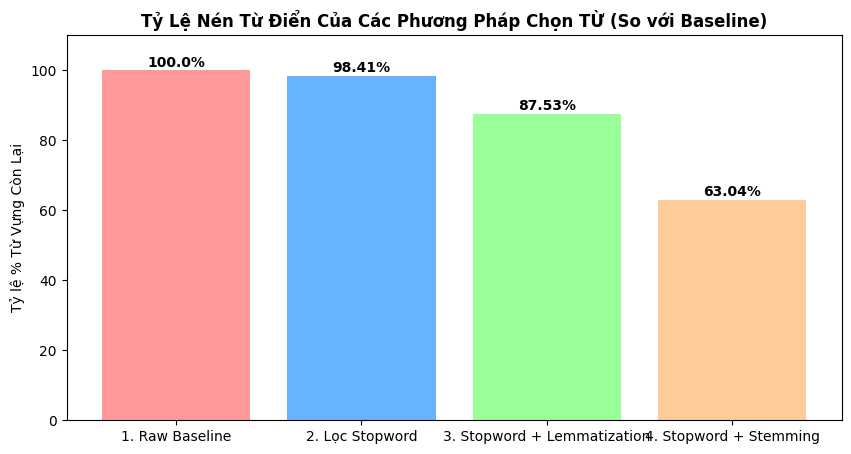

In [33]:
def get_vocab_stats(process_func, documents):
    all_tokens = []
    for text in documents.values():
        all_tokens.extend(process_func(text))
    return len(all_tokens), len(set(all_tokens)), Counter(all_tokens)

print("Đang phân tích toàn bộ từ điển Cranfield...")
raw_tot, raw_voc, _ = get_vocab_stats(selector.p1_raw, documents)
sw_tot, sw_voc, _ = get_vocab_stats(selector.p2_stopword, documents)
lem_tot, lem_voc, _ = get_vocab_stats(selector.p4_lemmatization, documents)
stem_tot, stem_voc, stem_counter = get_vocab_stats(selector.p3_stemming, documents)

vocab_data = [
    {"Pipeline": "1. Raw Baseline", "Tổng số Term": raw_tot, "Kích thước Từ điển (Vocab)": raw_voc, "Tỷ lệ so với gốc (%)": 100.0},
    {"Pipeline": "2. Lọc Stopword", "Tổng số Term": sw_tot, "Kích thước Từ điển (Vocab)": sw_voc, "Tỷ lệ so với gốc (%)": (sw_voc/raw_voc)*100},
    {"Pipeline": "3. Stopword + Lemmatization", "Tổng số Term": lem_tot, "Kích thước Từ điển (Vocab)": lem_voc, "Tỷ lệ so với gốc (%)": (lem_voc/raw_voc)*100},
    {"Pipeline": "4. Stopword + Stemming", "Tổng số Term": stem_tot, "Kích thước Từ điển (Vocab)": stem_voc, "Tỷ lệ so với gốc (%)": (stem_voc/raw_voc)*100}
]

df_vocab = pd.DataFrame(vocab_data)
display(df_vocab)

print("\n=> TOP 20 TERMS XUẤT HIỆN NHIỀU NHẤT (SAU KHI DÙNG STEMMING):")
for term, count in stem_counter.most_common(20):
    print(f"  + {term}: {count}")

# Vẽ biểu đồ Tỷ lệ nén
plt.figure(figsize=(10, 5))
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
bars = plt.bar(df_vocab['Pipeline'], df_vocab['Tỷ lệ so với gốc (%)'], color=colors)
plt.title('Tỷ Lệ Nén Từ Điển Của Các Phương Pháp Chọn TỪ (So với Baseline)', fontweight='bold')
plt.ylabel('Tỷ lệ % Từ Vựng Còn Lại')
plt.ylim(0, 110)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{round(yval, 2)}%", ha='center', fontweight='bold')
plt.show()

### BƯỚC 5: Đánh giá Hiệu quả Chọn Term (BM25 Retrieval)

Đang đánh giá mô hình: 1. Raw (Baseline)...
Đang đánh giá mô hình: 2. Stopword Only...
Đang đánh giá mô hình: 3. Stopword + Lemmatization...
Đang đánh giá mô hình: 4. Stopword + Stemming...


,Pipeline,MAP@10,Mean P@10,Mean Recall@10
0,1. Raw (Baseline),0.2193,0.2107,0.3551
1,2. Stopword Only,0.2389,0.2311,0.3911
2,3. Stopword + Lemmatization,0.2462,0.2347,0.3940
3,4. Stopword + Stemming,0.2574,0.2356,0.3990


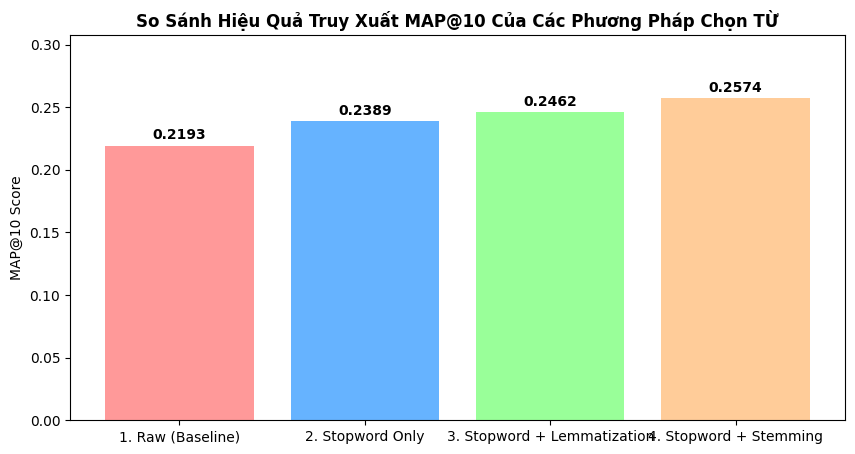

In [34]:
def calc_map_and_metrics(retrieved, relevant, k=10):
    retrieved_k = retrieved[:k]
    relevant_set = set(relevant)
    
    true_pos = len([doc for doc in retrieved_k if doc in relevant_set])
    precision = true_pos / k if k > 0 else 0
    recall = true_pos / len(relevant_set) if len(relevant_set) > 0 else 0
    
    ap = 0.0
    hits = 0
    for i, doc in enumerate(retrieved_k):
        if doc in relevant_set:
            hits += 1
            ap += hits / (i + 1.0)
            
    if len(relevant_set) > 0:
        ap = ap / min(len(relevant_set), k)
        
    return precision, recall, ap

def evaluate_pipeline(name: str, process_func, documents, queries, qrels):
    print(f"Đang đánh giá mô hình: {name}...")
    doc_ids = list(documents.keys())
    doc_texts = list(documents.values())
    
    tokenized_corpus = [process_func(doc) for doc in doc_texts]
    bm25 = BM25Okapi(tokenized_corpus)
    
    sum_p = 0; sum_r = 0; sum_ap = 0
    valid_queries = 0
    
    for q_id, q_text in queries.items():
        if q_id not in qrels or len(qrels[q_id]) == 0: continue
        
        tokenized_query = process_func(q_text)
        scores = bm25.get_scores(tokenized_query)
        top_10_indices = scores.argsort()[::-1][:10]
        top_10_doc_ids = [doc_ids[idx] for idx in top_10_indices]
        
        p, r, ap = calc_map_and_metrics(top_10_doc_ids, qrels[q_id], k=10)
        sum_p += p; sum_r += r; sum_ap += ap
        valid_queries += 1
        
    return {
        "Pipeline": name,
        "MAP@10": round(sum_ap / valid_queries, 4),
        "Mean P@10": round(sum_p / valid_queries, 4),
        "Mean Recall@10": round(sum_r / valid_queries, 4)
    }

results = []
results.append(evaluate_pipeline("1. Raw (Baseline)", selector.p1_raw, documents, queries, qrels))
results.append(evaluate_pipeline("2. Stopword Only", selector.p2_stopword, documents, queries, qrels))
results.append(evaluate_pipeline("3. Stopword + Lemmatization", selector.p4_lemmatization, documents, queries, qrels))
results.append(evaluate_pipeline("4. Stopword + Stemming", selector.p3_stemming, documents, queries, qrels))

df_results = pd.DataFrame(results)
display(df_results)

# Vẽ biểu đồ MAP@10
plt.figure(figsize=(10, 5))
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
bars = plt.bar(df_results['Pipeline'], df_results['MAP@10'], color=colors)
plt.title('So Sánh Hiệu Quả Truy Xuất MAP@10 Của Các Phương Pháp Chọn TỪ', fontweight='bold')
plt.ylabel('MAP@10 Score')
plt.ylim(0, max(df_results['MAP@10']) + 0.05)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 4), ha='center', fontweight='bold')
plt.show()